# TP-2 — TinyGPT: instruction tuning and LoRA

Author: Msc. Abraham R.

You will take the TinyGPT you pretrained in TP-1 and teach it to follow instructions, then
fine-tune it in two directions.

## From pretraining to fine-tuning

TP-1 left you a model that continues Shakespeare. It cannot follow an instruction, because
nothing in its training data ever looked like one. Pretraining and fine-tuning run the same
loss on the same architecture; four things change:

| | Pretraining | Fine-tuning |
|---|---|---|
| Data | raw text, billions of tokens | curated pairs, thousands |
| Loss | every token | **response tokens only** |
| Learning rate | high | 1-2 orders of magnitude lower |
| Format | none | a template with special tokens |

This is the supervised fine-tuning (SFT) stage behind instruction-following models like:
- InstructGPT / ChatGPT
- Llama-2-Chat
- Alpaca, and the many LoRA adapters built on open models

**Part 1 — Supervised fine-tuning.** Build an instruction dataset, wrap it in a chat
template, and fine-tune every parameter. The supervised loss sees the answer only.

**Part 2 — Parameter-efficient fine-tuning.** Replace full fine-tuning with **LoRA**, and
measure what each fine-tune cost the model in what it already knew.

The base model is TP-1's and does not change: every task fine-tunes a copy of it.

## Tasks

**Part 1**
- Task I — build the SFT dataset with **prompt loss masking**.
- Task II — full fine-tuning, and evaluation.

**Part 2**
- Task III — implement **LoRA** from scratch and compare it against full fine-tuning.
- Task IV — measure **catastrophic forgetting** on the pretraining distribution.

**Then**
- Task V — port your TP-1 `generateV2` into a **chat** function.
- Task VI — read the **attention** at the answer position.
- *Optional* — show that pretraining bought you something.

## How to work on this

**Prerequisites:** TP-1 including **Task X (a real tokenizer)** — this notebook loads
`./checkpoints/tp1_subword/checkpoint_final.pt`, and pretrains its own base model if that
is missing.

Task I ships with a `check_dataset()` cell, and the LoRA cell asserts that the adapted
model starts identical to the base. Run them before training — they cost seconds and catch
the bugs that would otherwise show up as a flat loss curve after the whole fine-tune.

**Keep `./checkpoints/`.** TP-3 continues from the model you fine-tune here rather than
training a new one. You do not hand the checkpoints in — but if you delete them, you will
have to retrain.

References: [LoRA](https://arxiv.org/abs/2106.09685) ·
[InstructGPT](https://arxiv.org/abs/2203.02155) · [PEFT](https://huggingface.co/docs/peft)

In [1]:
import copy
import math
import os
import random
import re
from collections import Counter
from typing import Dict, List, Optional, Tuple

from transformers import AutoTokenizer

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR, StepLR
from torch.utils.data import DataLoader, Dataset

from tinygpt import (
    CharDataset,
    GPTConfig,
    TinyGPT,
    count_parameters,
    describe,
    generate,
    get_device,
    load_checkpoint,
    load_tinyshakespeare,
    plot_losses,
    run_training,
    trim_kv_cache,
)
from trainer import Trainer

torch.manual_seed(1337)
random.seed(1337)

device = get_device()
print(f"device: {device}")

c:\Users\Administrator\Documents\GitHub\llm_pretraining_decoding_moe\tinygpt_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda


# Stage 0 — the pretrained base model

Same corpus, same tokenizer and same config as TP-1, so the TP-1 checkpoint drops straight in.

In [3]:
PRETRAIN_CHARS = 100_000    # exactly what TP-1 pretrained on -- fixed, so Task IV stays comparable
NUM_WORKERS = 0
TP1_CKPT = "../checkpoints/tp1_subword/checkpoint_final.pt"

# The base model is TP-1's and does not change: same architecture, same tokenizer, same
# 100k characters. The one thing this notebook *can* scale is the fine-tune, so the
# instruction words are mined from the whole corpus while the language-modelling data
# stays the slice the checkpoint was actually trained on.
sft_text = load_tinyshakespeare(None)
text = sft_text[:PRETRAIN_CHARS]

# The same tokenizer TP-1 Task X pretrained with, so its checkpoint drops straight in.
tokenizer = AutoTokenizer.from_pretrained("gpt2")
base_vocab_size = len(tokenizer)

# tie_weights=False: the TP-1 checkpoints keep token_emb and head as two separate
# matrices. load_checkpoint refuses to load those into a tied model rather than
# silently dropping one of them.
config = GPTConfig(vocab_size=base_vocab_size, tie_weights=False)
data = torch.tensor(tokenizer(text, add_special_tokens=False)["input_ids"], dtype=torch.long)
split = int(0.9 * len(data))

# Kept around for Task IV: the pretraining distribution we will check for forgetting.
shakespeare_val_loader = DataLoader(CharDataset(data[split:], config.block_size),
                                   batch_size=config.batch_size, shuffle=False,
                                   drop_last=True, num_workers=NUM_WORKERS)

print(config)
print(f"pretraining slice  {len(text):>9,} chars -> {len(data):,} tokens "
      f"({len(text) / len(data):.2f} chars/token)")
print(f"SFT word corpus    {len(sft_text):>9,} chars")


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (30645 > 1024). Running this sequence through the model will result in indexing errors


GPTConfig(block_size=32, batch_size=64, n_embd=64, n_head=4, n_layer=2, dropout=0.1, vocab_size=50257, bias=True, tie_weights=False, ff_class=None, moe_args=None)
pretraining slice    100,000 chars -> 30,645 tokens (3.26 chars/token)
SFT word corpus    1,115,394 chars


In [4]:
base_model = TinyGPT(config).to(device)

if os.path.exists(TP1_CKPT):
    # load_checkpoint tolerates the "_orig_mod." prefix a torch.compile'd CUDA run leaves
    # on every key.
    load_checkpoint(base_model, TP1_CKPT, map_location=device)
    print(f"loaded pretrained weights from {TP1_CKPT}")
else:
    print("no TP-1 Task X checkpoint found, pretraining from scratch")
    print("(run TP-1 Task X first if you want the exact same base model)")
    pretrain_loader = DataLoader(CharDataset(data[:split], config.block_size),
                                 batch_size=config.batch_size, shuffle=True,
                                 drop_last=True, num_workers=NUM_WORKERS)
    opt = AdamW(base_model.parameters(), lr=1e-3)
    trainer = Trainer(model=base_model, train_data_loader=pretrain_loader,
                      test_data_loader=shakespeare_val_loader,
                      loss_fn=torch.nn.CrossEntropyLoss(), gradient_accumulation_steps=1,
                      optimizer=opt, scheduler=StepLR(opt, step_size=100, gamma=0.9),
                      device=device, save_dir="./checkpoints/tp2_base", save_every_n=500)
    run_training(trainer, epochs=2)

describe(base_model, "base model")

loaded pretrained weights from ../checkpoints/tp1_subword/checkpoint_final.pt
base model: 6,535,040 parameters | 6,535,040 trainable (100.00%)


c:\Users\Administrator\Documents\GitHub\llm_pretraining_decoding_moe\TP2\tinygpt.py:493: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=

## What this stands in for

The method is the real one; the scale and the data are not.

| | this notebook | a real pipeline |
|---|---|---|
| pretraining | 100k characters of one playwright | 10^12+ tokens, months of GPU time |
| SFT data | ~29k pairs from one corpus | 10^4–10^6 curated pairs, often human-written |
| stages | pretrain → SFT | pretrain → SFT → preference tuning (RLHF / DPO / GRPO) |
| evaluation | exact match + conditioning | benchmark suites, human preference, LLM-as-judge |

Identical at both scales: the loss, prompt masking, the embedding resize, the LoRA
factorisation, and the forgetting trade-off. Those are the transferable parts.

**Set your expectations.** 6.5M parameters pretrained on 30,645 tokens will not write good
Shakespeare — `continue` returns things like `",\nAnd I'll be not, and I am,"`. That is the
correct outcome at this scale, not a mistake you made. Judge the run by the metrics — does
the output depend on the prompt, does `who_said` beat its 3.5% baseline — and read the
samples for mechanism, not for quality.

# The instruction dataset

Three instructions sharing one chat template, chosen to differ in **kind**:

| task | kind | answer | can this model do it? |
|---|---|---|---|
| `continue` | generative | the next ~12 tokens of the corpus | **yes** — the pretraining objective wearing a template |
| `who_said` | classification | a speaker's name | maybe — 98 classes, 3.5% majority baseline |
| `reverse` | string transform | the word backwards | **no**, and provably so |

Mixing a task the model can do with one it cannot is deliberate: when everything scores
zero you cannot tell a hard task from a broken notebook. With `continue` working, a zero
on `reverse` *means* something.

`continue` ships in four phrasings — `continue:`, `go on:`, `what comes next:`,
`finish this:` — and the last is **held out of training**. A model that memorised four
strings fails on it; one that learned "this is a continuation request" does not.

Everything is mined from the whole 1.1M-character corpus, not the 100k slice the base
model saw. The base model is TP-1's and does not change, so the instruction data is the
only lever this notebook has.

## What the tokenizer does to `reverse`

Under byte-level BPE the transform is **not position-local**:

| word | tokens | reversed | tokens |
|---|---|---|---|
| `sword` | `['sword']` | `drows` | `['d', 'rows']` |
| `citizen` | `['c', 'itizen']` | `nezitic` | `['ne', 'z', 'itic']` |
| `hamlet` | `['ham', 'let']` | `telmah` | `['tel', 'm', 'ah']` |

Only ~2 words in 10 keep their token count, and reversed English is close to a random byte
string, so BPE shreds it — 2.00 characters per token against 3.31 for the input. The model
must map one token sequence onto a differently-segmented one, inferring the segmentation
of an output it has not produced yet.

**This is why production LLMs are bad at character-level work** — counting letters,
reversing strings, spelling backwards. The information is there in principle, but the
tokenizer threw away the alignment that would make it easy.

A near-zero score on `reverse` is therefore the correct result. What matters is that you
can explain it — and say why `continue`, in the same template with the same loss and the
same optimizer, does not suffer from it.

In [5]:
USER, ASSISTANT, END, PAD = "<|user|>", "<|assistant|>", "<|end|>", "<|pad|>"

# Three instructions sharing one template, deliberately different in kind:
#
#   continue  generative, and it rides the distribution TP-1 already pretrained on, so it
#             is the one the model can actually do. Four phrasings, so the model has to
#             generalise over *how* it was asked rather than memorise one string.
#   who_said  classification. The answer is a speaker name, so exact match is meaningful
#             and there is a real chance level (~3.5%) to beat. Fluent-sounding output
#             cannot fake this one.
#   reverse   a control that the tokenizer makes impossible -- see the segmentation note
#             above. It is here to fail, and to be explained.
#
# A task set that mixes "can do" with "provably cannot" is the point: with every task
# failing you cannot tell a hard task from a broken notebook.

CONTINUE_PHRASINGS = ["continue:", "go on:", "what comes next:", "finish this:"]
HELD_OUT_PHRASING = "finish this:"      # never seen in training -- see the Task II questions

Example = Tuple[str, str, str]          # (task, user text, answer text)


def format_example(ex: Example) -> Tuple[str, str]:
    """Returns (prompt, answer). The answer carries the END token; the prompt does not."""
    _, body, answer = ex
    return f"{USER}{body}{ASSISTANT}", f"{answer}{END}"


def build_continue(ids: List[int], n_prefix: int = 12, n_answer: int = 12,
                   phrasings=None) -> List[Example]:
    """Non-overlapping (prefix -> continuation) slices of the corpus, wrapped in the template."""
    phrasings = phrasings or CONTINUE_PHRASINGS
    step, out = n_prefix + n_answer, []
    for i in range(0, len(ids) - step, step):
        prefix = tokenizer.decode(ids[i:i + n_prefix])
        answer = tokenizer.decode(ids[i + n_prefix:i + step])
        out.append(("continue", f"{random.choice(phrasings)} {prefix}", answer))
    return out


def build_who_said(pairs: List[Tuple[str, str]], budget: int) -> List[Example]:
    """(speaker, speech) -> ask who spoke. The line is truncated to whatever fits."""
    out = []
    for speaker, speech in pairs:
        line = " ".join(speech.split())
        room = budget - len(tokenizer.encode(f"{USER}who said: {ASSISTANT}")) \
                      - len(tokenizer.encode(speaker + END))
        if room < 5:
            continue
        out.append(("who_said", f"who said: {tokenizer.decode(tokenizer.encode(line)[:room])}",
                    speaker))
    return out


def build_reverse(words: List[str]) -> List[Example]:
    return [("reverse", f"reverse: {w}", w[::-1]) for w in words]


# ---- sources -------------------------------------------------------------------------
sft_ids = tokenizer(sft_text, add_special_tokens=False)["input_ids"]

speeches = re.findall(r"^([A-Z][A-Za-z' ]{1,30}):\n((?:.+\n)+)", sft_text, flags=re.M)
speaker_counts = Counter(s for s, _ in speeches)
speeches = [(s, t) for s, t in speeches if speaker_counts[s] >= 20]   # 98 speakers

words = sorted({w for w in re.findall(r"[A-Za-z]+", sft_text) if 3 <= len(w) <= 10})

# ---- split each source before building, so nothing leaks across the split -------------
BUDGET = config.block_size + 1
cut_ids, cut_sp, cut_w = int(.9 * len(sft_ids)), int(.9 * len(speeches)), int(.9 * len(words))
random.shuffle(speeches)
random.shuffle(words)

# The held-out phrasing never appears in training: Task II asks whether the model
# generalises over instruction wording or memorised the four strings.
train_phrasings = [p for p in CONTINUE_PHRASINGS if p != HELD_OUT_PHRASING]

train_examples = (build_continue(sft_ids[:cut_ids], phrasings=train_phrasings)
                  + build_who_said(speeches[:cut_sp], BUDGET)
                  + build_reverse(words[:cut_w]))
val_examples = (build_continue(sft_ids[cut_ids:])
                + build_who_said(speeches[cut_sp:], BUDGET)
                + build_reverse(words[cut_w:]))
random.shuffle(train_examples)
random.shuffle(val_examples)

TASKS = ("continue", "who_said", "reverse")
print(f"{len(train_examples):,} train | {len(val_examples):,} val")
for t in TASKS:
    n_tr = sum(1 for e in train_examples if e[0] == t)
    n_va = sum(1 for e in val_examples if e[0] == t)
    print(f"   {t:<9} {n_tr:>7,} train  {n_va:>6,} val")

print("\none of each:")
for t in TASKS:
    ex = next(e for e in train_examples if e[0] == t)
    print(f"   {''.join(format_example(ex))!r}")

# What the tokenizer does to `reverse`: the transform is not position-local.
print()
for w in ("sword", "citizen", "hamlet"):
    seg = lambda s: [tokenizer.decode([i]) for i in tokenizer.encode(s)]
    print(f"{w:<9} {str(seg(w)):<24} -> reverse {seg(w[::-1])}")


29,381 train | 3,266 val
   continue   12,675 train   1,408 val
   who_said    5,365 train     597 val
   reverse    11,341 train   1,261 val

one of each:
   '<|user|>continue:  mind he is\nWere damnable.\n\nProvost<|assistant|>:\nHere in the prison, father,\nThere died<|end|>'
   "<|user|>who said: Go, nurse, go with her: we'll to<|assistant|>CAPULET<|end|>"
   '<|user|>reverse: distressed<|assistant|>dessertsid<|end|>'

sword     ['sword']                -> reverse ['d', 'rows']
citizen   ['c', 'itizen']          -> reverse ['ne', 'z', 'itic']
hamlet    ['ham', 'let']           -> reverse ['tel', 'm', 'ah']


## Special tokens and embedding resize

The four template markers are not characters, so the pretrained vocabulary has no ids
for them. Appending them keeps every learned id stable, and
`resize_token_embeddings` grows the embedding matrix and the output head while
preserving every pretrained row. The new rows start random — remember that for Task III.

In [6]:
special_ids = tokenizer.add_special_tokens(
    {"additional_special_tokens": [USER, ASSISTANT, END, PAD]})
PAD_ID = tokenizer.convert_tokens_to_ids(PAD)
END_ID = tokenizer.convert_tokens_to_ids(END)

base_model.resize_token_embeddings(len(tokenizer))

print(f"vocab {base_vocab_size:,} -> {len(tokenizer):,} (+{special_ids} reserved ids)")
describe(base_model, "base model (resized)")

demo = "".join(format_example(train_examples[0]))
print(repr(demo))
print("->", tokenizer.encode(demo), [tokenizer.decode([i]) for i in tokenizer.encode(demo)])


vocab 50,257 -> 50,261 (+4 reserved ids)
base model (resized): 6,535,552 parameters | 6,535,552 trainable (100.00%)
'<|user|>continue:  mind he is\nWere damnable.\n\nProvost<|assistant|>:\nHere in the prison, father,\nThere died<|end|>'
-> [50257, 43043, 25, 220, 2000, 339, 318, 198, 35653, 12270, 540, 13, 198, 198, 15946, 455, 50258, 25, 198, 4342, 287, 262, 3770, 11, 2988, 11, 198, 1858, 3724, 50259] ['<|user|>', 'continue', ':', ' ', ' mind', ' he', ' is', '\n', 'Were', ' damn', 'able', '.', '\n', '\n', 'Prov', 'ost', '<|assistant|>', ':', '\n', 'Here', ' in', ' the', ' prison', ',', ' father', ',', '\n', 'There', ' died', '<|end|>']


# Task I — the SFT dataset and prompt loss masking

The single most important difference between pretraining and supervised fine-tuning:
**the supervised loss is computed on the response only.** Training the model to predict
the prompt teaches it to generate instructions, and it drowns the signal you want in
tokens the user will always supply.

## The objective, following GPT-1

Radford et al. (2018), §3.3, write fine-tuning as a supervised term plus the pretraining
term carried along:

$$L_2(\mathcal{C}) = \sum_{(x,y)} \log P(y \mid x^1, \dots, x^m)$$

$$L_3(\mathcal{C}) = L_2(\mathcal{C}) + \lambda \, L_1(\mathcal{C})$$

$L_2$ is cross-entropy on the **answer tokens only** — exactly what prompt masking
produces. $L_1$ is ordinary language modelling over the same sequences: predict **every**
token, prompt included. The paper reports that keeping $L_1$ in the mix *"improved
generalization"* and *"accelerated convergence"*. Here it does something else as well: it
keeps the model a language model at all.

Both terms are read off **one** label row. $L_2$'s targets are a strict subset of $L_1$'s
with the same token values — only the positions differ — so a single row suffices if each
entry records which objectives claim it:

| entry | position | claimed by |
|---|---|---|
| `-100` | padding | neither |
| `id` | prompt token | $L_1$ |
| `id + ANSWER_OFFSET` | answer token | $L_1$ **and** $L_2$ |

Two rows would read better, but `Trainer` flattens targets with `.view(B * T)`, which
asserts the size — widening it means editing `trainer.py`, which TP-1 also imports.

**Recipe**

1. `prompt, answer = format_example(ex)` — `ex` is a `(task, user text, answer)` triple.
2. `prompt_ids = tokenizer.encode(prompt)`, `answer_ids = tokenizer.encode(answer)`,
   `full = prompt_ids + answer_ids`.
3. `labels = prompt_ids + [i + ANSWER_OFFSET for i in answer_ids]`, same length as `full`.
4. Pad `full` with `PAD_ID` and `labels` with `IGNORE`, up to `block_size + 1`.
5. `x = full[:-1]`, `y = labels[1:]`. Both `torch.long`, both `(block_size,)`.

**Why the shift.** The model at position `t` predicts token `t + 1`, so the target for
`x[t]` is `labels[t + 1]`. Get it backwards and the model learns to copy its input — the
loss drops and the generations are garbage.

In [8]:
IGNORE_INDEX = -100
# Answer targets are stored as `token_id + ANSWER_OFFSET` so that one label row can say
# which objectives claim each position. See InstructionDataset below.
ANSWER_OFFSET = len(tokenizer)


class InstructionDataset(Dataset):
    """
    Supervised fine-tuning dataset with prompt loss masking.
    """

    def __init__(self, examples: List[Tuple[str, str]], tokenizer,
                 block_size: int, pad_id: int, ignore_index: int = IGNORE_INDEX):
        self.examples = examples
        self.tokenizer = tokenizer
        self.block_size = block_size
        self.pad_id = pad_id
        self.ignore_index = ignore_index

    def __len__(self) -> int:
        return len(self.examples)

    def __getitem__(self, idx: int):
        # 1. template: prompt = "<|user|>...<|assistant|>", answer = "...<|end|>"
        prompt, answer = format_example(self.examples[idx])

        # 2. tokenise each part separately, so we know exactly where the answer starts
        prompt_ids = self.tokenizer.encode(prompt)
        answer_ids = self.tokenizer.encode(answer)
        full = prompt_ids + answer_ids

        # 3. one label row for both objectives: prompt tokens stay plain ids (L1 only),
        #    answer tokens are shifted by ANSWER_OFFSET (L1 and L2)
        labels = prompt_ids + [i + ANSWER_OFFSET for i in answer_ids]

        # block_size + 1 tokens: the extra one is consumed by the shift below.
        # If an example is too long, drop tokens from the *start* of the prompt so the
        # answer and the <|assistant|> marker before it are always kept intact.
        size = self.block_size + 1
        if len(full) > size:
            full, labels = full[-size:], labels[-size:]

        # 4. pad: inputs with PAD_ID, labels with ignore_index (a target for neither loss)
        n_pad = size - len(full)
        full = full + [self.pad_id] * n_pad
        labels = labels + [self.ignore_index] * n_pad

        # 5. shift: the model at position t predicts token t+1
        x = torch.tensor(full[:-1], dtype=torch.long)
        y = torch.tensor(labels[1:], dtype=torch.long)
        return x, y
    
        raise NotImplementedError

## Self-check

In [9]:
def check_dataset():
    ds = InstructionDataset(train_examples, tokenizer, config.block_size, PAD_ID)
    x, y = ds[0]

    assert x.shape == (config.block_size,), f"x: {x.shape}"
    assert y.shape == (config.block_size,), f"y: {y.shape}"
    assert x.dtype == torch.long and y.dtype == torch.long

    prompt, answer = format_example(ds.examples[0])

    # decode the row the same way the loss does
    is_answer = y >= ANSWER_OFFSET
    lm_row = torch.where(is_answer, y - ANSWER_OFFSET, y)
    sft_row = torch.where(is_answer, lm_row, torch.full_like(y, IGNORE_INDEX))

    # L1 supervises the prompt as well as the answer, so it must cover strictly more
    assert int((lm_row != IGNORE_INDEX).sum()) > int((sft_row != IGNORE_INDEX).sum()), \
        "the L1 row must supervise more positions than the L2 row"
    # and neither objective may ever target a pad
    assert not ((x == PAD_ID) & (lm_row != IGNORE_INDEX)).any(), "padding is being supervised"

    # exactly the answer tokens are supervised by L2
    supervised = (sft_row != IGNORE_INDEX)
    assert int(supervised.sum()) == len(tokenizer.encode(answer)), (
        f"{int(supervised.sum())} != {len(tokenizer.encode(answer))}")

    # and the supervised targets reconstruct the answer
    recovered = tokenizer.decode(sft_row[supervised].tolist())
    assert recovered == answer, f"{recovered!r} != {answer!r}"

    # the shift is right: y[t] is the token that follows x[t]
    t = int(supervised.nonzero()[0])
    full = tokenizer.encode(prompt + answer)
    assert int(x[t]) == full[t] and int(sft_row[t]) == full[t + 1]

    print(f"prompt   {prompt!r}")
    print(f"answer   {answer!r}")
    print(f"x        {tokenizer.decode(x[x != PAD_ID].tolist())!r}")
    print(f"L2 targets  {recovered!r} ({int(supervised.sum())}/{config.block_size} positions)")
    print(f"L1 targets  {int((lm_row != IGNORE_INDEX).sum())}/{config.block_size} positions")
    print("all checks passed")


check_dataset()

prompt   '<|user|>continue:  mind he is\nWere damnable.\n\nProvost<|assistant|>'
answer   ':\nHere in the prison, father,\nThere died<|end|>'
x        '<|user|>continue:  mind he is\nWere damnable.\n\nProvost<|assistant|>:\nHere in the prison, father,\nThere died<|end|>'
L2 targets  ':\nHere in the prison, father,\nThere died<|end|>' (13/32 positions)
L1 targets  29/32 positions
all checks passed


## Packing and replay

Two adjustments sit between the dataset and the optimizer. Both are standard practice and
both change the result here, so they are worth understanding before you read the numbers.

**Packing.** One example per 32-token block wastes ~71% of every batch on padding — but
the bigger problem is *where* it leaves the supervision. With one short example per block,
answers only ever appear at positions 4–12; positions 16–31 never receive a single
instruction gradient. A model can then satisfy the training set with a positional shortcut
— *"emit an answer around position 5"* — instead of the rule you want, *"emit an answer
after `<|assistant|>`"*. Both fit the data perfectly; only one survives a longer prompt,
and a chat request with a system prompt or a second turn is exactly that. Concatenating
examples until the block is full removes both problems at once.

**Replay.** GPT-1 computes $L_1$ over the fine-tuning corpus $\mathcal{C}$ itself. Ours is
narrow — one corpus, three instruction types — so $L_1$ alone does little to hold the model
near the distribution TP-1 pretrained it on — which is what Task IV measures. Replay
widens $L_1$'s corpus with raw pretraining text.

Mix it by **supervised positions, not example count**. An instruction example supervises
~4 of 32 positions while a replay example supervises all 32, so one replay item carries
roughly nine instruction items' worth of gradient — counting examples, "25%" would in fact
be 68% of $L_1$.

In [10]:
class PackedInstructionDataset(Dataset):
    """
    Examples concatenated into full blocks instead of one padded example per block.

    Removes both the padding waste and the positional shortcut described above. Caveat:
    without a block-diagonal mask a packed example can attend to the one before it, which
    most implementations accept.
    """

    def __init__(self, examples: List[Tuple[str, str]], tokenizer,
                 block_size: int, pad_id: int, ignore_index: int = IGNORE_INDEX):
        self.block_size, self.pad_id, self.ignore_index = block_size, pad_id, ignore_index
        size = block_size + 1                      # one extra, consumed by the shift
        self.blocks, self.n_supervised = [], 0
        full, labels = [], []

        for ex in examples:
            prompt, answer = format_example(ex)
            p, a = tokenizer.encode(prompt), tokenizer.encode(answer)
            if len(p) + len(a) > size:
                continue                           # cannot fit alone; nothing here does
            if len(full) + len(p) + len(a) > size:
                self.blocks.append(self._pack(full, labels))
                full, labels = [], []
            full += p + a
            labels += p + [i + ANSWER_OFFSET for i in a]
            self.n_supervised += len(a)
        if full:
            self.blocks.append(self._pack(full, labels))

    def _pack(self, full: List[int], labels: List[int]):
        size = self.block_size + 1
        pad = size - len(full)
        full = full + [self.pad_id] * pad
        labels = labels + [self.ignore_index] * pad   # padding is a target in neither
        return (torch.tensor(full[:-1], dtype=torch.long),
                torch.tensor(labels[1:], dtype=torch.long))

    def __len__(self) -> int:
        return len(self.blocks)

    def __getitem__(self, idx: int):
        return self.blocks[idx]


class ReplayDataset(Dataset):
    """
    Instruction examples with a slice of the pretraining corpus mixed back in.

    Replay items are plain next-token prediction, so both kinds of example share one loss
    function and sit in the same batch.
    """

    def __init__(self, sft: Dataset, lm: Dataset, n_replay: int):
        self.sft, self.lm = sft, lm
        self.n_replay = n_replay

    def __len__(self) -> int:
        return len(self.sft) + self.n_replay

    def __getitem__(self, idx: int):
        if idx < len(self.sft):
            return self.sft[idx]
        # No ANSWER_OFFSET on raw labels, so a replay sequence feeds L1 and not L2.
        return self.lm[(idx - len(self.sft)) % len(self.lm)]


class SFTWithAuxLM(nn.Module):
    """
    GPT-1's fine-tuning objective:  L3 = L2 + lambda * L1.

    Both terms come off one forward pass. Each is a per-token mean over its own supervised
    positions, so `lambda` weights comparable quantities; `clamp(min=1)` keeps a batch with
    no answer tokens at 0 instead of NaN.
    """

    def __init__(self, offset: int = ANSWER_OFFSET, lam: float = 0.5,
                 ignore_index: int = IGNORE_INDEX):
        super().__init__()
        self.offset, self.lam, self.ignore_index = offset, lam, ignore_index

    def _per_token(self, logits, targets):
        total = F.cross_entropy(logits, targets,
                                ignore_index=self.ignore_index, reduction="sum")
        return total / (targets != self.ignore_index).sum().clamp(min=1)

    def forward(self, logits, targets):
        # Undo the dataset's encoding. Answer positions were stored offset; everything
        # else is already a plain token id, or -100 for padding.
        is_answer = targets >= self.offset
        lm = torch.where(is_answer, targets - self.offset, targets)
        sft = torch.where(is_answer, lm, torch.full_like(lm, self.ignore_index))
        return self._per_token(logits, sft) + self.lam * self._per_token(logits, lm)


AUX_LM_LAMBDA = 0.5      # the lambda of L3 = L2 + lambda * L1, as in the GPT-1 paper
REPLAY_SHARE = 0.25      # share of L1's corpus drawn from pretraining text, by tokens

sft_train = PackedInstructionDataset(train_examples, tokenizer, config.block_size, PAD_ID)
lm_train = CharDataset(data[:split], config.block_size)

# What packing bought, measured rather than asserted.
_padded = InstructionDataset(train_examples, tokenizer, config.block_size, PAD_ID)
_pad_free = 100 * sft_train.n_supervised / (len(sft_train) * config.block_size)
print(f"padded : {len(_padded):>6,} blocks, "
      f"{100 * sft_train.n_supervised / (len(_padded) * config.block_size):4.1f}% of positions are L2 targets")
print(f"packed : {len(sft_train):>6,} blocks, {_pad_free:4.1f}% -- "
      f"{len(_padded) / len(sft_train):.1f}x fewer blocks for the same supervision\n")

# Mixed by supervised positions, not by example count -- see the note above.
sft_positions = sft_train.n_supervised
n_replay = int(REPLAY_SHARE / (1 - REPLAY_SHARE) * sft_positions / config.block_size)

sft_train_loader = DataLoader(
    ReplayDataset(sft_train, lm_train, n_replay),
    batch_size=config.batch_size, shuffle=True, drop_last=True, num_workers=NUM_WORKERS)
# Validation stays instructions-only and unpacked, so its loss is a clean per-token number.
sft_val_loader = DataLoader(
    InstructionDataset(val_examples, tokenizer, config.block_size, PAD_ID),
    batch_size=config.batch_size, shuffle=False, drop_last=True, num_workers=NUM_WORKERS)

replay_positions = n_replay * config.block_size
print(f"instructions {len(sft_train):>7,} blocks   -> {sft_positions:>9,} L2 targets"
      f"  ({100 * sft_positions / (sft_positions + replay_positions):4.1f}% of L1's corpus)")
print(f"replay       {n_replay:>7,} blocks   -> {replay_positions:>9,} L1 targets"
      f"  ({100 * replay_positions / (sft_positions + replay_positions):4.1f}%)")
print(f"{len(sft_train_loader)} train batches | {len(sft_val_loader)} val batches "
      f"(instructions only)")

padded : 29,381 blocks, 25.5% of positions are L2 targets
packed : 23,216 blocks, 32.2% -- 1.3x fewer blocks for the same supervision

instructions  23,216 blocks   ->   239,587 L2 targets  (75.0% of L1's corpus)
replay         2,495 blocks   ->    79,840 L1 targets  (25.0%)
401 train batches | 51 val batches (instructions only)


# Task II — full fine-tuning

Every parameter is trainable, at a learning rate an order of magnitude below pretraining.
Too high and you erase the pretrained weights before they can be reused — one of the
things Task IV measures.

Evaluation reports exact match on training and held-out examples for the two tasks with a
single right answer, `who_said` and `reverse`. `continue` is generative, so exact match is
meaningless there; it is scored by `continuation_quality` — cross-entropy on the answer
tokens, plus the share of continuations scoring better under **their own** prefix than a
stranger's.

That last number is the one to watch. 50% is chance: fluent Shakespeare with no relation
to what you asked. A generative task can look like a success to the eye and fail this
outright.

The training mix also carries a **replay** fraction of raw Shakespeare (`REPLAY_SHARE`),
because instruction data alone pulls the model off its pretraining distribution hard
enough to stop it being a language model — which is what Task IV measures.

In [11]:
@torch.no_grad()
def generate_until(model, prompt: str, stop_id: int = None, max_new_tokens: int = 24) -> str:
    """Greedy decoding that stops at the END token. Returns only the generated part."""
    model.eval()
    stop_id = END_ID if stop_id is None else stop_id
    dev = next(model.parameters()).device
    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=dev)[None, :]
    kv, produced = None, []

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -model.config.block_size:] if kv is None else idx[:, -1:]
        logits, kv = model(idx_cond, kv_cache=kv, use_cache=True)
        kv = trim_kv_cache(kv, model.config.block_size - 1)
        nxt = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        if int(nxt) == stop_id:
            break
        produced.append(int(nxt))
        idx = torch.cat((idx, nxt), dim=1)

    return tokenizer.decode(produced)


@torch.no_grad()
def answer_loss(model, prompt: str, answer: str) -> float:
    """Cross-entropy on the answer tokens of one (prompt, answer) pair."""
    p, a = tokenizer.encode(prompt), tokenizer.encode(answer)
    ids = (p + a)[: model.config.block_size + 1]
    x = torch.tensor(ids[:-1], device=device)[None, :]
    y = torch.tensor(ids[1:], device=device)[None, :]
    tgt = torch.full_like(y, IGNORE_INDEX)
    tgt[:, len(p) - 1:] = y[:, len(p) - 1:]          # the shift again: x[t] predicts y[t]
    logits = model(x)
    return F.cross_entropy(logits.reshape(-1, logits.size(-1)), tgt.reshape(-1),
                           ignore_index=IGNORE_INDEX).item()


@torch.no_grad()
def continuation_quality(model, examples, n: int = 120) -> Dict[str, float]:
    """
    `loss` is cross-entropy on the answer tokens, in the same units as the pretraining loss.

    `conditioned` is the share of continuations scoring better under their own prefix than
    under a stranger's. 50% is chance: fluent output that ignores the prompt. A generative
    task can look successful to the eye and still fail this.
    """
    sample = [e for e in examples if e[0] == "continue"][:n]
    if not sample:
        return {}
    losses, wins = [], 0
    for i, ex in enumerate(sample):
        prompt, answer = format_example(ex)
        other_prompt = format_example(sample[(i + 1) % len(sample)])[0]
        own = answer_loss(model, prompt, answer)
        losses.append(own)
        wins += own < answer_loss(model, other_prompt, answer)
    return {"loss": sum(losses) / len(sample), "conditioned": wins / len(sample)}


EXACT_MATCH_TASKS = ("who_said", "reverse")   # `continue` has no single right string


@torch.no_grad()
def show_continuations(model, examples, k: int = 3, max_new_tokens: int = 18) -> None:
    """Read what the generative task actually produces. Not a metric -- a sanity check."""
    for ex in [e for e in examples if e[0] == "continue"][:k]:
        prompt, answer = format_example(ex)
        print(f"   ask  {prompt[len(USER):-len(ASSISTANT)]!r}")
        print(f"   got  {generate_until(model, prompt, max_new_tokens=max_new_tokens)!r}")
        print(f"   true {answer[:-len(END)]!r}")


@torch.no_grad()
def evaluate_instructions(model, examples, n: int = 150, verbose: int = 5) -> Dict[str, float]:
    """Exact match, for the two tasks that have exactly one right string."""
    # `continue` is not decoded: its exact match is 0.0% by construction and the decodes
    # are the most expensive thing here. It is scored by `continuation_quality` instead.
    hits = {t: [0, 0] for t in EXACT_MATCH_TASKS}
    sample = [e for e in examples if e[0] in EXACT_MATCH_TASKS][:n]

    for i, ex in enumerate(sample):
        task = ex[0]
        prompt, answer = format_example(ex)
        expected = answer[: -len(END)]
        got = generate_until(model, prompt, max_new_tokens=14)   # these answers are short
        hits[task][1] += 1
        hits[task][0] += int(got == expected)
        if i < verbose:
            mark = "OK " if got == expected else "XX "
            print(f"   {mark} {task:>8}: {got[:36]!r:<38} want {expected[:26]!r}")

    acc = {t: c / max(k, 1) for t, (c, k) in hits.items()}
    acc["overall"] = sum(c for c, _ in hits.values()) / max(sum(k for _, k in hits.values()), 1)
    print("   " + " | ".join(f"{k}={v:.1%}" for k, v in acc.items()))
    return acc


@torch.no_grad()
def evaluate_both(model, name: str, n: int = 150):
    """Training vs held-out. The gap is memorisation against learning."""
    print(f"### {name}")
    print("  -- exact match, training examples --")
    acc_train = evaluate_instructions(model, train_examples, n=n, verbose=0)
    print("  -- exact match, held-out examples --")
    acc_val = evaluate_instructions(model, val_examples, n=n, verbose=4)
    print(f"  gap: {acc_train['overall'] - acc_val['overall']:+.1%}")
    q = continuation_quality(model, val_examples)
    if q:
        print(f"  -- continue (generative) --")
        print(f"   answer loss {q['loss']:.3f} | prompt-conditioned {q['conditioned']:.1%}"
              f"   (50% = ignoring the prompt)")
        show_continuations(model, val_examples)
    return acc_train, acc_val


In [12]:
print(f"### base model, before fine-tuning")
acc_base = evaluate_instructions(base_model, val_examples, n=60)

### base model, before fine-tuning
   XX  who_said: ',\nAnd,\nAnd the,\nAnd the, the,'     want 'QUEEN MARGARET'
   XX   reverse: '\n\nAnd, the,\nAnd,\nAnd the,\n'      want 'nierehw'
   XX   reverse: '\nAnd,\nThe,\nAnd the,\nAnd the,'     want 'sedivorp'
   XX   reverse: ',\nAnd, the,\nAnd the,\nAnd the,'     want 'deyd'
   XX  who_said: ',\nAnd,\nAnd,\nThe,\nAnd, the'        want 'CLIFFORD'
   who_said=0.0% | reverse=0.0% | overall=0.0%


In [13]:
def param_groups(model: nn.Module, weight_decay: float = 0.01):
    """
    Weight decay on the matrices only.

    AdamW decays every parameter in the group each step, including the ~47,000 embedding
    rows a given batch never touched. GPT-2 and nanoGPT both split the groups this way.
    """
    no_decay_prefix = ("token_emb", "pos_emb", "head")
    decay, no_decay = [], []
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        (no_decay if p.ndim < 2 or name.startswith(no_decay_prefix) else decay).append(p)
    return [{"params": decay, "weight_decay": weight_decay},
            {"params": no_decay, "weight_decay": 0.0}]


def cosine_with_warmup(opt, total_steps: int, warmup_frac: float = 0.05):
    """
    Linear warmup, then cosine decay to zero, defined against the whole run.

    Warmup matters because step 0 of a fine-tune pairs a pretrained body with freshly
    random embedding rows; hitting those at full learning rate wrecks the pretrained
    weights. Defining the schedule against `total_steps` rather than a fixed step count
    keeps it meaningful when the dataset size changes.
    """
    warmup = max(1, int(total_steps * warmup_frac))

    def scale(step: int) -> float:
        if step < warmup:
            return (step + 1) / warmup
        progress = (step - warmup) / max(1, total_steps - warmup)
        return 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))

    return LambdaLR(opt, scale)


FT_EPOCHS = 10          # ~9 min on an M3 Pro now that the SFT set is 5x bigger
FT_LR = 3e-4
FT_STEPS = FT_EPOCHS * len(sft_train_loader)

full_ft_model = copy.deepcopy(base_model).to(device)
for p in full_ft_model.parameters():
    p.requires_grad_(True)
describe(full_ft_model, "full fine-tuning")

opt = AdamW(param_groups(full_ft_model), lr=FT_LR)
full_trainer = Trainer(
    model=full_ft_model,
    train_data_loader=sft_train_loader,
    test_data_loader=sft_val_loader,
    loss_fn=SFTWithAuxLM(lam=AUX_LM_LAMBDA),
    gradient_accumulation_steps=1,
    optimizer=opt,
    scheduler=cosine_with_warmup(opt, FT_STEPS),
    device=device,
    save_dir="./checkpoints/tp2_full_ft",
    save_every_n=500,
)

history_full = run_training(full_trainer, epochs=FT_EPOCHS)

full fine-tuning: 6,535,552 parameters | 6,535,552 trainable (100.00%)
mixed precision: on (bfloat16)


val_loss 11.19750: 100%|██████████| 51/51 [00:06<00:00,  7.92it/s]


epoch 1/10 | train 11.0272 | val 10.8887


val_loss 9.11148: 100%|██████████| 51/51 [00:07<00:00,  6.89it/s]


epoch 2/10 | train 9.4937 | val 9.3283


...

epoch 8/10 | train 7.5733 | val 7.5795


val_loss 7.16495: 100%|██████████| 51/51 [00:06<00:00,  7.46it/s]


epoch 9/10 | train 7.6175 | val 7.5696


val_loss 7.16154: 100%|██████████| 51/51 [00:06<00:00,  7.74it/s]


epoch 10/10 | train 7.5914 | val 7.5670


In [14]:
acc_full_train, acc_full = evaluate_both(full_ft_model, "after full fine-tuning")

### after full fine-tuning
  -- exact match, training examples --
   who_said=7.1% | reverse=0.0% | overall=2.0%
  -- exact match, held-out examples --
   XX  who_said: 'QUEEN ELIZABETH'                      want 'QUEEN MARGARET'
   XX   reverse: ''                                     want 'nierehw'
   XX   reverse: ''                                     want 'sedivorp'
   XX   reverse: ''                                     want 'deyd'
   who_said=20.8% | reverse=0.0% | overall=7.3%
  gap: -5.3%
  -- continue (generative) --
   answer loss 5.419 | prompt-conditioned 65.8%   (50% = ignoring the prompt)
   ask  'continue:  here you sty me\nIn this hard rock, whiles'
   got  '\nAnd the the a,\nAnd the the'
   true " you do keep from me\nThe rest o' the island"
   ask  'go on:  for the mischance of\nthe hour, if it so'
   got  '\nAnd, and the the the,\nAnd'
   true ' hap. Cheerly, good hearts! Out\n'
   ask  'what comes next: , bountiful Fortune,\nNow my dear lady, hath'
   got  '\nAnd,\n

In [16]:
# ── Task II, Q5: the held-out phrasing against the three seen ones (inference only) ──
def rephrase(ex, phrasing):
    """Same prefix and answer, asked with another phrasing."""
    task, body, answer = ex
    old = next(p for p in CONTINUE_PHRASINGS if body.startswith(p))
    return task, phrasing + body[len(old):], answer


cont_val = [e for e in val_examples if e[0] == "continue"][:300]
print(f"{len(cont_val)} held-out continue examples, each asked with all four phrasings\n")
print(f"{'phrasing':<18} {'answer loss':>11} {'cond.':>7} {'terminates':>11} {'mean len':>9}")
for ph in CONTINUE_PHRASINGS:
    exs = [rephrase(e, ph) for e in cont_val]
    q = continuation_quality(full_ft_model, exs, n=len(exs))
    lens = [len(tokenizer.encode(generate_until(full_ft_model, format_example(e)[0])))
            for e in exs[:60]]
    stopped = sum(L < 24 for L in lens) / len(lens)
    tag = "  <- held out" if ph == HELD_OUT_PHRASING else ""
    print(f"{ph:<18} {q['loss']:11.3f} {q['conditioned']:7.1%} "
          f"{stopped:11.1%} {sum(lens) / len(lens):9.1f}{tag}")

print("\nsame prefix, four phrasings (greedy):")
for ph in CONTINUE_PHRASINGS:
    prompt = format_example(rephrase(cont_val[0], ph))[0]
    print(f"  {ph:<18} {generate_until(full_ft_model, prompt, max_new_tokens=18)!r}")

300 held-out continue examples, each asked with all four phrasings

phrasing           answer loss   cond.  terminates  mean len
continue:                5.446   65.7%      100.0%       6.2
go on:                   5.389   69.7%      100.0%      10.0
what comes next:         5.407   73.3%      100.0%       9.9
finish this:             5.497   71.0%      100.0%       2.2  <- held out

same prefix, four phrasings (greedy):
  continue:          '\nAnd the the a,\nAnd the the'
  go on:             '\nAnd, and the,\nAnd the the'
  what comes next:   '\nAnd, the,\nAnd the the'
  finish this:       '\nAnd, the'


In [18]:
# ── Task II, Q6: experiment (b), AUX_LM_LAMBDA = 0.0 -- L2 only, so replay does nothing ──
import json

EXP_LAMBDA = 0.0
EXP_DIR = "./checkpoints/tp2_exp_lambda0"

exp_model = copy.deepcopy(base_model).to(device)
for p in exp_model.parameters():
    p.requires_grad_(True)

if os.path.exists(f"{EXP_DIR}/checkpoint_final.pt"):
    # Already trained: reload the weights and the loss history instead of training again.
    load_checkpoint(exp_model, f"{EXP_DIR}/checkpoint_final.pt", map_location=device)
    with open(f"{EXP_DIR}/history.json") as fh:
        history_exp = json.load(fh)
    print(f"loaded {EXP_DIR}")
    for e, (tr, va) in enumerate(zip(history_exp["train"], history_exp["val"]), 1):
        print(f"epoch {e}/{len(history_exp['train'])} | train {tr:.4f} | val {va:.4f}")
else:
    opt = AdamW(param_groups(exp_model), lr=FT_LR)
    exp_trainer = Trainer(
        model=exp_model,
        train_data_loader=sft_train_loader,      # same data, replay included
        test_data_loader=sft_val_loader,
        loss_fn=SFTWithAuxLM(lam=EXP_LAMBDA),
        gradient_accumulation_steps=1,
        optimizer=opt,
        scheduler=cosine_with_warmup(opt, FT_STEPS),
        device=device,
        save_dir=EXP_DIR,
        save_every_n=500,
    )
    history_exp = run_training(exp_trainer, epochs=FT_EPOCHS)

loaded ./checkpoints/tp2_exp_lambda0
epoch 1/10 | train 7.5031 | val 7.5184
epoch 2/10 | train 6.4883 | val 6.3436
epoch 3/10 | train 5.7315 | val 5.5978
epoch 4/10 | train 5.3401 | val 5.2960
epoch 5/10 | train 5.1161 | val 5.1531
epoch 6/10 | train 5.1215 | val 5.0774
epoch 7/10 | train 5.1430 | val 5.0335
epoch 8/10 | train 5.0583 | val 5.0086
epoch 9/10 | train 5.0689 | val 5.0001
epoch 10/10 | train 4.9767 | val 4.9987


c:\Users\Administrator\Documents\GitHub\llm_pretraining_decoding_moe\TP2\tinygpt.py:493: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(path, map_location=

In [19]:
@torch.no_grad()
def mean_loss(model, loader, loss_fn) -> float:
    """Mean of `loss_fn` over `loader`, in eval mode."""
    model.eval()
    total, n = 0.0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        B, T, C = out.shape
        total += loss_fn(out.view(B * T, C).float(), y.view(B * T)).item()
        n += 1
    return total / n


# L2 alone: the trainer's val loss includes lambda * L1, so it is not comparable across lambdas.
# Shakespeare: plain next-token loss on the pretraining val split, as Task IV will measure it.
l2_only, plain_lm = SFTWithAuxLM(lam=0.0), nn.CrossEntropyLoss()

acc_exp_train, acc_exp = evaluate_both(exp_model, f"full ft, lambda = {EXP_LAMBDA}")

print(f"\n{'':20s} {'L2 val':>7s} {'who_said':>9s} {'cont loss':>10s} {'cond.':>6s} "
      f"{'Shakesp.':>9s} {'terminates':>11s} {'mean len':>9s}")
for name, m, acc in (("full ft, lambda 0.5", full_ft_model, acc_full),
                     (f"full ft, lambda {EXP_LAMBDA}", exp_model, acc_exp)):
    q = continuation_quality(m, val_examples)
    lens = [len(tokenizer.encode(generate_until(m, format_example(ex)[0])))
            for ex in val_examples[:60]]
    print(f"{name:20s} {mean_loss(m, sft_val_loader, l2_only):7.3f} {acc['who_said']:9.1%} "
          f"{q['loss']:10.3f} {q['conditioned']:6.1%} "
          f"{mean_loss(m, shakespeare_val_loader, plain_lm):9.3f} "
          f"{sum(L < 24 for L in lens) / len(lens):11.1%} {sum(lens) / len(lens):9.1f}")

# The same plain-text prefix Task IV uses: no template, does it still continue a play?
exp_prefix = tokenizer.decode(data[split:split + 16].tolist())
for name, m in (("full ft, lambda 0.5", full_ft_model), (f"full ft, lambda {EXP_LAMBDA}", exp_model)):
    torch.manual_seed(0)
    out = generate(m, tokenizer, exp_prefix, max_new_tokens=24)
    print(f"\n### {name}, no template\n{out[len(exp_prefix):]!r}")

### full ft, lambda = 0.0
  -- exact match, training examples --
   who_said=7.1% | reverse=0.0% | overall=2.0%
  -- exact match, held-out examples --
   XX  who_said: 'QUEEN ELIZABETH'                      want 'QUEEN MARGARET'
   XX   reverse: ''                                     want 'nierehw'
   XX   reverse: ''                                     want 'sedivorp'
   XX   reverse: ''                                     want 'deyd'
   who_said=13.2% | reverse=0.0% | overall=4.7%
  gap: -2.7%
  -- continue (generative) --
   answer loss 5.461 | prompt-conditioned 60.0%   (50% = ignoring the prompt)
   ask  'continue:  here you sty me\nIn this hard rock, whiles'
   got  '\nAnd'
   true " you do keep from me\nThe rest o' the island"
   ask  'go on:  for the mischance of\nthe hour, if it so'
   got  '\nAnd, and,\nAnd,\nAnd'
   true ' hap. Cheerly, good hearts! Out\n'
   ask  'what comes next: , bountiful Fortune,\nNow my dear lady, hath'
   got  ',\nAnd, the, and the the,\n'
   true ' 

## Questions

1. Rank the three tasks and explain the ranking by **what each one asks the model to
   compute**, not by how hard it feels. One of them is the pretraining objective in
   disguise; say which, and why that makes it nearly free.
2. `continue` is scored by prompt-conditioning, not exact match. Why is exact match the
   wrong metric here? Describe a model that scores well on the samples a human reads while
   scoring 50% on the conditioning test — what is that model actually doing?
3. `reverse` cannot work. Output position `t` needs input position `L-1-t` at the
   *character* level: explain why that is not expressible as "attend k tokens back".
   Then connect it to the wild — production LLMs miscount letters and fail at reversing
   words. Capability failure, or tokenization artefact? What would fix it, and at what cost?
4. `PackedInstructionDataset` makes answers land at every position instead of only
   positions 4-12. Describe what a model trained on the padded version could learn that
   scores perfectly on this validation set and fails the first time it is served behind a
   chat API with a system prompt.
5. `finish this:` never appears in training; the other three `continue` phrasings do.
   Compare behaviour on the held-out phrasing against the seen ones (inference only, no
   retraining). If it degrades, the model memorised strings rather than learning the
   instruction — and that distinction is most of what "instruction tuning" means.
6. **One experiment — choose one, on one model.** Predict the outcome first, then run it.
   - (a) turn prompt masking off, so $L_2$ covers the prompt too; or
   - (b) set `AUX_LM_LAMBDA` to `0.0` or `2.0`; or
   - (c) raise `FT_LR` by 10x.

   Report what moved and what did not, and explain the mechanism. A correct prediction
   that the run contradicts is worth more than a safe one — say why you were wrong.

---

1. The ranking is continue, then who_said, then reverse. continue is the pretraining objective in disguise as, given a prefix, the model has to predict the next tokens. Wrapping it in a template only adds a few tokens to ignore, so the model already knows how to do it, beign free. Its answer loss after fine-tuning (5.42) is close to the base model’s loss on plain Shakespeare (5.51), and its continuations depend on the prompt 65.8% of the time. who_said is a classification task where the model has to map a line of text to one of the charachters names. That needs associations between words and speakers, which the model only partialy has. It reached 20.8% on held-out examples, against a 3.5% baseline. Since the sample has about 53 who_said examples, that is 11 correct answers, so the number is noisy. Even the one wrong answer shown (QUEEN ELIZABETH for a QUEEN MARGARET line) names a character from the same plays. reverse asks for a character-level operation that the tokenizer hides, and it stayed at 0% on every model.

2. A continuation has many correct answers. Even a perfect model of Shakespeare would almost never produce the exact 12 tokens of the original, so exact match would be close to 0% for every model and could not tell them apart. A model can read well and still score 50% on the conditioning test if it ignores the prompt and always writes the most common Shakespeare-like text. It works as a language model without conditioning by producing the average of the corpus. Our samples look like that. The full fine-tune answers with small variations of '\nAnd the the a,\nAnd the the' to all three prompts, and the model trained from scratch gives very similar lines like ',\nAnd I am, and I'll the king,' for different prompts. Still, the conditioning test gives 65–66%, so the model does use the prompt. Greedy decoding hides it, because it always picks the most likely tokens.

3. Attention moves information between token positions. “Attend k tokens back” works when the needed input sits at a fixed distance in tokens. For reversal, the needed is a character, and characters do not line up with tokens. sword is one token and drows is two (d, rows), so the first output token needs the last letter of an input token, and the second output token needs the first four letters of the same input token in reverse order. The offset depends on how both strings happen to be split, and the letters inside a token are not visible in its embedding. The model would have to have memorised the spelling of every token. One fix is to work on characters or bytes level. The cost is sequences about 3 times longer here, so attention costs more and a 32-token window holds a third of the text. Other fixes are to let the model spell the word out letter by letter before answering, which costs output tokens, or to call a tool that runs code.

4. With padding, each block holds one short example, so <|assistant|> and the answer always appear in the same small range of positions. The model can learn to answer based on position, for example “start the answer around position 8” or “stop after a few tokens counted from the start”, instead of answering after <|assistant|>. The validation set is built the same way, so this shortcut scores just as well there. Behind a chat API, a system prompt or a previous turn makes the prompt longer, and <|assistant|> lands near position 25. A model with the positional shortcut would start answering in the middle of the user’s text, or not recognise where its turn starts. Packing puts answers at every position and places examples one after another, which looks much more like a multi-turn chat.

5. I asked the same 300 held-out prefixes with each of the four phrasings, so the only thing that changes between runs is the wording. On content, the held-out phrasing works as well as the seen ones. Its conditioning is 71%, which falls inside the range of the three seen phrasings (65% to 73%), and its answer loss is only a little higher (5.497 against 5.389–5.446). The model still continues the prefix it was given, which means it learned the instruction and did not just memorise the exact strings. What does change is when it stops. With “finish this” the replies average 2.2 tokens, against 6.2 to 10 for the seen phrasings, and the greedy sample for the same prefix is just ‘\nAnd, the’. So the reply length seems to have been learned together with the phrasing. My guess is that an unknown marker pushes the model toward the short answers of who_said and reverse, although I did not test that. Also, the differences among the seen phrasings (65% against 73%) are about as large as the gap to the held-out one, so with 300 examples the conditioning numbers carry a few points of noise.

6. I chose (b), AUX_LM_LAMBDA = 0.0, so the loss covers answer tokens only. Since replay sequences have no answer tokens, replay also stops having any effect. My prediction was that the Shakespeare loss would rise above the base model’s, that the instruction metrics would stay the same or improve a little, that plain-text generation would contain even more template tokens, and that the trainer’s val loss would look much lower.

As a result, against the λ = 0.5 model, the Shakespeare loss went from 5.318 to 5.845, above the base model’s 5.514, so this time forgetting does show. The loss on the answers improved slightly (L2 val 4.999 against 5.024), and the trainer’s val loss fell to 5 only because it no longer includes L1. Those parts I predicted correctly. The instruction metrics went the other way: conditioning dropped from 65.8% to 60%, the continue answer loss rose from 5.419 to 5.461, and who_said fell from 20.8% to 13.2%. Termination stayed at 100%, reverse at 0%, and the mean length barely moved (5.1 against 4.6). I was wrong because I thought of L1 as competing with the answers, when here it was helping them. The prompts of continue and who_said are Shakespeare text too, so L1 gave the model more language-modelling signal on the same material the answers need. Without it, the model fits the answer tokens a bit better and generalises worse. Part of that drop is just noise, who_said is 11 against 7 correct out of 53, and conditioning is measured on 120 examples. Plain-text generation did not get worse in the way I expected. It shows fewer kinds of template tokens, but once it emits <|end|> it repeats it until the end (11 times in a row). With λ = 0 nothing after <|end|> is ever supervised, because only the answers count, so the model never learned what comes after the end of an answer.


# Task III — LoRA from scratch

LoRA freezes the pretrained weight $W_0$ and learns a low-rank update instead:

$$W = W_0 + \frac{\alpha}{r} B A, \qquad A \in \mathbb{R}^{r \times d_{in}},\; B \in \mathbb{R}^{d_{out} \times r}$$

With $r \ll d$, $BA$ has far fewer parameters than $W_0$. $B$ starts at **zeros** so that
$W = W_0$ at step 0 and fine-tuning begins exactly from the pretrained model.

Implement `LoRALinear` as a wrapper around an `nn.Linear`, then `apply_lora` to swap the
wrapped modules into a model in place.

**Hints**
- Freeze the base weight and bias. Init `A` with `normal_(std=1/r)` and `B` with zeros —
  randomising `B` injects noise into a trained model at step 0.
- Build `A` and `B` on `base.weight.device` and dtype; the model is already on the GPU.
- `forward(x) = self.base(x) + (alpha/r) * (dropout(x) @ A.T @ B.T)`.
- In `apply_lora`, collect replacements from `named_modules()` into a list first, then
  `setattr(parent, name, LoRALinear(child, ...))`. Targets: `key_query_value` and `proj`.

**The trap.** Fine-tuning added template tokens whose embedding rows are random, and no
gradient path reaches a frozen `nn.Embedding` — so if LoRA freezes everything except the
adapters, the model can never learn to emit `<|end|>` and never stops generating. PEFT
calls the fix `modules_to_save`.

**But do not simply unfreeze the embedding.** At `n_embd=64` the embedding and output head
are **98.4% of this model** — 6.4M of 6.5M parameters, against 102k for the projections
LoRA adapts. Unfreezing them wholesale means "parameter-efficient" fine-tuning trains 98%
of the parameters.

So the question is not *whether* to unfreeze vocabulary rows, but **which**. Keep
`requires_grad=True` on the matrix and mask the gradient of every row you are not adapting:

```python
mask = torch.zeros(w.shape[0], 1, device=w.device, dtype=w.dtype)
mask[trainable_rows] = 1.0
w.register_hook(lambda g, m=mask: g * m)
```

The cell below prints three scopes:

| rows unfrozen | trainable | |
|---|---|---|
| the template tokens only | 0.10% | the least that terminates at all |
| the SFT vocabulary | ~27% | **what this notebook trains** |
| the whole embedding | 98.44% | not fine-tuning by any useful definition |

The middle is what you would do when adapting to a new domain vocabulary, and the share
depends on the task — a wide one like `continue` touches far more rows than a narrow one.
It is not only about parameter count: TP-1's pretraining touched just **3,558 of 50,257
rows**, so most tokens an answer needs sit at their random init, and a frozen output head
cannot grow them.

One detail that silently ruins Task IV: AdamW decays any parameter that *has* a gradient,
and a masked gradient is zero, not absent. Put those rows in their own parameter group
with `weight_decay=0.0`.

Report **both** numbers in your write-up: what `count_parameters` claims, and what can
actually move.

In [20]:
class LoRALinear(nn.Module):
    """
    Wraps a frozen nn.Linear with a trainable low-rank update.
    """

    def __init__(self, base: nn.Linear, r: int = 8, alpha: int = 16, dropout: float = 0.0):
        super().__init__()
        # TODO: Task III
        self.base = base
        self.r, self.alpha = r, alpha
        self.scaling = alpha / r

        # W0 (and its bias) are frozen: only the low-rank update learns.
        self.base.weight.requires_grad_(False)
        if self.base.bias is not None:
            self.base.bias.requires_grad_(False)

        # Same device/dtype as the wrapped layer -- the model is already on the GPU.
        kw = dict(device=base.weight.device, dtype=base.weight.dtype)
        # A: (r, d_in), small random.  B: (d_out, r), zeros -> B A = 0, so W = W0 at step 0.
        self.A = nn.Parameter(torch.empty(r, base.in_features, **kw).normal_(std=1.0 / r))
        self.B = nn.Parameter(torch.zeros(base.out_features, r, **kw))
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        # raise NotImplementedError

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: base output + scaled low-rank update
        # W0 x + (alpha / r) * B A x   -- never materialises the d_out x d_in matrix B A
        return self.base(x) + self.scaling * (self.dropout(x) @ self.A.T @ self.B.T)
        # raise NotImplementedError


def apply_lora(model: nn.Module, r: int = 8, alpha: int = 16,
               targets: Tuple[str, ...] = ("key_query_value", "proj"),
               trainable_rows: Optional[List[int]] = None) -> nn.Module:
    """
    Replaces the targeted nn.Linear submodules with LoRALinear, freezes everything
    that is not a LoRA parameter, and returns the model.

    `trainable_rows` are the only embedding/head rows allowed to learn -- the vocabulary
    the fine-tune actually uses. See the note above.
    """
    # TODO: Task III
    # 1. freeze the whole pretrained model; the adapters created below start trainable
    for p in model.parameters():
        p.requires_grad_(False)

    # 2. collect first, then replace: mutating the module tree while named_modules() is
    #    iterating over it would skip or revisit modules
    to_wrap = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and name.split(".")[-1] in targets:
            parent_name, _, child_name = name.rpartition(".")
            to_wrap.append((model.get_submodule(parent_name), child_name, module))
    for parent, child_name, child in to_wrap:
        setattr(parent, child_name, LoRALinear(child, r=r, alpha=alpha))

    # 3. the trap: let only the chosen vocabulary rows of token_emb and head learn.
    #    requires_grad stays on for the whole matrix; a hook zeroes the gradient of every
    #    other row. (Those rows still carry a zero gradient, so they must sit in a group with
    #    weight_decay=0.0 -- param_groups already puts token_emb and head there.)
    if trainable_rows:
        seen = set()
        for w in (model.token_emb.weight, model.head.weight):
            if id(w) in seen:                       # tied weights: one tensor, one hook
                continue
            seen.add(id(w))
            mask = torch.zeros(w.shape[0], 1, device=w.device, dtype=w.dtype)
            mask[torch.as_tensor(list(trainable_rows), device=w.device)] = 1.0
            w.requires_grad_(True)
            w.register_hook(lambda g, m=mask: g * m)

    return model
    # raise NotImplementedError

In [21]:
# The rows resize_token_embeddings appended -- what the trap is about.
NEW_TOKEN_IDS = list(range(base_vocab_size, len(tokenizer)))

# Every token appearing in a training prompt or answer. Contains NEW_TOKEN_IDS already.
SFT_TOKEN_IDS = sorted({i for ex in train_examples
                        for part in format_example(ex)
                        for i in tokenizer.encode(part)})

lora_model = apply_lora(copy.deepcopy(base_model).to(device), r=8, alpha=16,
                        trainable_rows=SFT_TOKEN_IDS)


def trainable_breakdown(model, trainable_rows) -> Tuple[int, int]:
    """
    (adapter params, embedding-row params) that can actually receive a gradient.

    count_parameters() calls a whole matrix trainable whenever requires_grad is True,
    so on a gradient-masked embedding it over-counts by every row the mask zeroes.
    """
    adapters = rows = 0
    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue
        if name.endswith(".A") or name.endswith(".B"):
            adapters += p.numel()
        else:
            rows += len(trainable_rows) * p.shape[1]
    return adapters, rows


total, naive = count_parameters(lora_model)
adapters, rows = trainable_breakdown(lora_model, SFT_TOKEN_IDS)
n_emb_mat = 1 if lora_model.head.weight is lora_model.token_emb.weight else 2
row_cost = config.n_embd * n_emb_mat          # params per unfrozen vocabulary row
describe(full_ft_model, "full fine-tuning")
describe(lora_model, "LoRA")

# requires_grad is a claim; the mask is the truth.
print(f"\n  requires_grad claims  {naive:>10,} / {total:,} ({100 * naive / total:6.2f}%)")
print(f"  can actually move     {adapters + rows:>10,} / {total:,} "
      f"({100 * (adapters + rows) / total:6.2f}%)")

# Which rows you unfreeze is a spectrum, and the choice is the whole lesson.
print("\n  how much of the vocabulary you unfreeze:")
for label, ids in (("the 4 template tokens", NEW_TOKEN_IDS),
                   ("the SFT vocabulary", SFT_TOKEN_IDS),
                   ("the whole embedding", range(len(tokenizer)))):
    n = adapters + len(ids) * row_cost
    mark = "  <- this run" if len(ids) == len(SFT_TOKEN_IDS) else ""
    print(f"    {label:<22} {len(ids):>6,} rows  {n:>10,}  {100 * n / total:6.2f}%{mark}")
print(f"\n  {adapters:,} of that is the LoRA adapters themselves; the rest is vocabulary.")
print(f"  Embedding + head are {100 * (total - 102_144) / total:.1f}% of this model, which is why")
print("  'just unfreeze token_emb' and 'parameter-efficient' cannot both be true here.")

# Sanity check: with B initialised to zeros, LoRA must start out identical to the base.
base_model.eval()
lora_model.eval()  # dropout off, or the two forwards disagree for the wrong reason
probe = next(iter(sft_val_loader))[0][:2].to(device)
with torch.no_grad():
    delta = (lora_model(probe) - base_model(probe)).abs().max().item()
print(f"max |lora - base| at init: {delta:.2e}")
assert delta < 1e-5, "B must be initialised to zeros"

full fine-tuning: 6,535,552 parameters | 6,535,552 trainable (100.00%)
LoRA: 6,541,696 parameters | 6,439,552 trainable (98.44%)

  requires_grad claims   6,439,552 / 6,541,696 ( 98.44%)
  can actually move      1,747,712 / 6,541,696 ( 26.72%)

  how much of the vocabulary you unfreeze:
    the 4 template tokens       4 rows       6,656    0.10%
    the SFT vocabulary     13,606 rows   1,747,712   26.72%  <- this run
    the whole embedding    50,261 rows   6,439,552   98.44%

  6,144 of that is the LoRA adapters themselves; the rest is vocabulary.
  Embedding + head are 98.4% of this model, which is why
  'just unfreeze token_emb' and 'parameter-efficient' cannot both be true here.
max |lora - base| at init: 0.00e+00


mixed precision: on (bfloat16)


val_loss 10.41535: 100%|██████████| 51/51 [00:03<00:00, 15.27it/s]


epoch 1/10 | train 10.3878 | val 10.1753


val_loss 8.58834: 100%|██████████| 51/51 [00:03<00:00, 14.72it/s]


epoch 2/10 | train 8.9057 | val 8.8267


...

epoch 8/10 | train 7.5126 | val 7.4670


val_loss 7.02739: 100%|██████████| 51/51 [00:04<00:00, 12.37it/s]


epoch 9/10 | train 7.5590 | val 7.4501


val_loss 7.02497: 100%|██████████| 51/51 [00:03<00:00, 12.84it/s]


epoch 10/10 | train 7.5116 | val 7.4483


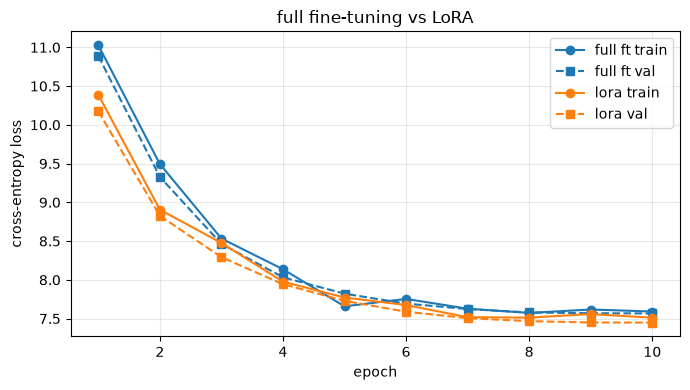

In [22]:
LORA_LR = 1e-3  # LoRA tolerates (and needs) a higher lr than full fine-tuning

# Two groups. AdamW decays every parameter that has a gradient, and the masked embedding's
# gradient is zero rather than absent -- so in the default group all 50,257 pretrained rows
# would shrink a little each step, and Task IV would measure weight decay, not forgetting.
# param_groups already puts token_emb and head in the no-decay group, which is what the
# masked rows need: AdamW decays whatever has a gradient, and a masked gradient is zero
# rather than absent, so in the default group every pretrained row would drift downward.
opt = AdamW(param_groups(lora_model), lr=LORA_LR)
lora_trainer = Trainer(
    model=lora_model,
    train_data_loader=sft_train_loader,
    test_data_loader=sft_val_loader,
    loss_fn=SFTWithAuxLM(lam=AUX_LM_LAMBDA),
    gradient_accumulation_steps=1,
    optimizer=opt,
    scheduler=cosine_with_warmup(opt, FT_STEPS),
    device=device,
    save_dir="./checkpoints/tp2_lora",
    save_every_n=500,
)

history_lora = run_training(lora_trainer, epochs=FT_EPOCHS)
plot_losses({"full ft": history_full, "lora": history_lora}, title="full fine-tuning vs LoRA")

In [23]:
acc_lora_train, acc_lora = evaluate_both(lora_model, "LoRA")

### LoRA
  -- exact match, training examples --
   who_said=2.4% | reverse=0.0% | overall=0.7%
  -- exact match, held-out examples --
   XX  who_said: 'DUKE VINCENTIO'                       want 'QUEEN MARGARET'
   XX   reverse: 'ss'                                   want 'nierehw'
   XX   reverse: 'ss'                                   want 'sedivorp'
   XX   reverse: 'ss'                                   want 'deyd'
   who_said=5.7% | reverse=0.0% | overall=2.0%
  gap: -1.3%
  -- continue (generative) --
   answer loss 5.392 | prompt-conditioned 60.8%   (50% = ignoring the prompt)
   ask  'continue:  here you sty me\nIn this hard rock, whiles'
   got  ',\nAnd,\nAnd, I the,\nAnd'
   true " you do keep from me\nThe rest o' the island"
   ask  'go on:  for the mischance of\nthe hour, if it so'
   got  ',\nAnd,\nAnd the stats, and,\n'
   true ' hap. Cheerly, good hearts! Out\n'
   ask  'what comes next: , bountiful Fortune,\nNow my dear lady, hath'
   got  '\nAnd,\nAnd, and the,\nAnd,'


### About count_parameters
`count_parameters` says 6,439,552 of 6,541,696 parameters are trainable (98.44%), because it counts any matrix with `requires_grad=True`. What can actually move is 1,747,712 (26.72%). Of those, 6,144 are the LoRA adapters and the rest are the 13,606 vocabulary rows in the embedding and the head (13,606 × 64 × 2). The adapters add 0.09% to the model. Almost all of the change comes from the unfrozen rows.

# Task IV — catastrophic forgetting

Fine-tuning moved the weights. Did it break what the model already knew?

Measure cross-entropy on the **original Shakespeare validation set** for all three
models (base, full fine-tuning, LoRA) and generate a Shakespeare continuation from
each. Note that this evaluation uses no template and no special tokens — it is exactly
the pretraining objective.

In [24]:
# TODO: Task IV
@torch.no_grad()
def shakespeare_loss(model) -> float:
    """
    Mean cross-entropy of `model` on shakespeare_val_loader.

    Hint: plain CrossEntropyLoss (no ignore_index -- every token counts here),
    logits.view(B * T, C) against y.view(B * T).
    """
    model.eval()                                   # dropout off: same weights -> same number
    dev = next(model.parameters()).device
    loss_fn = nn.CrossEntropyLoss(reduction="sum")  # sum, then divide once: exact per-token mean
    total, n_tokens = 0.0, 0
    for x, y in shakespeare_val_loader:
        x, y = x.to(dev), y.to(dev)
        logits = model(x)                          # (B, T, vocab) -- plain LM, no template
        B, T, C = logits.shape
        total += loss_fn(logits.view(B * T, C).float(), y.view(B * T)).item()
        n_tokens += B * T
    return total / n_tokens


for name, m in (("base", base_model), ("full ft", full_ft_model), ("lora", lora_model)):
    print(f"{name:>8}: {shakespeare_loss(m):.4f}")

    base: 5.5135
 full ft: 5.3183
    lora: 5.1744


In [25]:
# The same Shakespeare prefix (from the validation split, so none of them trained on it),
# same seed, no template: does each model still continue a play?
prefix_ids = data[split:split + 16].tolist()
prefix = tokenizer.decode(prefix_ids)
print(f"\nprefix: {prefix!r}")
print(f"truth : {tokenizer.decode(data[split + 16:split + 40].tolist())!r}")
for name, m in (("base", base_model), ("full ft", full_ft_model), ("lora", lora_model)):
    torch.manual_seed(0)
    out = generate(m, tokenizer, prefix, max_new_tokens=24)
    print(f"\n### {name}\n{out[len(prefix):]!r}")


prefix: ' collected them by tribes?\n\nAEdile:\nI have.\n'
truth : "\nSICINIUS:\nAssemble presently the people hither;\nAnd when they bear me say 'It"

### base
"\nThis these tore Rome together from'd mar be's, the let stats, being wounded hither prideoves his Vol"

### full ft
"think<|end|>ROMEO<|end|>continue together venom'd mar<|assistant|>'s,<|end|><|end|><|end|><|end|>W wounded<|end|><|end|><|end|><|end|> pal"

### lora
"think sunont th<|end|>continue together venom'd that<|assistant|>ps, lord<|end|><|user|>TER:\nBreverse<|end|><|user|><|user|>"


## Questions

No extra training for any of these.

1. Rank the three models by Shakespeare loss and by the instruction metrics. Is there a
   trade-off, and does LoRA sit where you expected?
2. Explain *mechanically* why constraining the update limits forgetting — what can full
   fine-tuning do to `W` that LoRA cannot? If LoRA nonetheless matched full fine-tuning
   here, what would that say about the intrinsic rank of this adaptation, and when would
   that stop being true?
3. You unfroze something beyond the adapters for LoRA to work at all. What, why was it
   unavoidable, and what stopped it from swallowing the parameter savings whole?

---

1. By loss on Shakespeare, LoRA was best (5.174), then full fine-tuning (5.318), then the base model (5.514). By the instruction metrics, full fine-tuning is ahead, with 20.8% on who_said against 5.7% for LoRA (11 against 3 correct out of 53), and 65.8% conditioning against 60.8%. On the continue answer loss LoRA is slightly better (5.392 against 5.419). So there is a trade-off in the expected direction, and LoRA sits where I expected keeping more of the language model and learning less of the instructions.

2. Full fine-tuning can change every weight in any direction, every attention and feed-forward matrix, the LayerNorms, and every row of the embedding and head. LoRA only adds B A of rank 8 to key_query_value and proj. The feed-forward layers and LayerNorms stay frozen, and the update to each matrix lives in an 8-dimensional subspace, so most of what the pretrained weights compute cannot be rewritten. That is the mechanism that limits forgetting. In this notebook the constraint is weaker than it sounds, because LoRA also trains 13,606 vocabulary rows at full rank with a learning rate 3.3 times higher (1e-3 against 3e-4), and those rows are 99.6% of what moves. On continue the two are close, LoRA has a slightly better answer loss (5.392 against 5.419) and 5 points less conditioning (60.8% against 65.8%). Where LoRA matches, the change the task needs has a low intrinsic rank, adapting to the template lies in a few directions. That stops being true when the task needs new knowledge or many independent changes, such as a new language or domain, many tasks at once, or a base model that knows too little. Our base model is close to that last case, which may be why who_said falls behind (5.7% against 20.8%).

3. I had to unfreeze rows of the embedding and of the output head. The four template tokens were added after pretraining, so their rows are random, and no gradient reaches a frozen nn.Embedding. Without training those rows the model cannot recognise <|assistant|> or produce <|end|>, and it never stops. Also, TP1 only trained 3,558 of the 50,257 rows, so most of the tokens the answers need were still at their random initialisation, and an adapter on attention cannot fix a row of the head. What kept this from taking all the savings was the gradient mask. register_hook sets to zero the gradient of every row outside the fine-tuning vocabulary, so 13,606 rows move (26.72%) instead of 50,261 (98.44%). Those rows were also left out of weight decay, so the rest do not shrink. It works, since LoRA stops on its own in 100% of cases with a mean length of 5.9 tokens. Even so, 26.72% is not very parameter-efficient. The minimum would be the 4 template rows (0.10%).

# the optional task — was pretraining worth anything?

Everything above assumes the pretrained model was a useful starting point. Test it.

Train a **randomly initialised** TinyGPT of the same size on the instruction data alone,
with the same schedule, and compare the loss curves and the accuracy against the
fine-tuned model.

Then answer: whatever gap you find, is it about *knowledge* (the model already knows the
alphabet and which letters follow which) or about *optimisation* (the pretrained weights
are simply in a better basin)? Propose an experiment that would separate the two.

from scratch: 6,535,552 parameters | 6,535,552 trainable (100.00%)
mixed precision: on (bfloat16)


val_loss 9.09420: 100%|██████████| 51/51 [00:03<00:00, 13.42it/s]


epoch 1/10 | train 9.2241 | val 9.1535


val_loss 7.77154: 100%|██████████| 51/51 [00:03<00:00, 13.42it/s]


epoch 2/10 | train 7.7686 | val 7.9547


...

epoch 8/10 | train 6.5102 | val 6.7334


val_loss 6.30123: 100%|██████████| 51/51 [00:04<00:00, 10.53it/s]


epoch 9/10 | train 6.5004 | val 6.7207


val_loss 6.30004: 100%|██████████| 51/51 [00:05<00:00,  9.96it/s]


epoch 10/10 | train 6.4272 | val 6.7196


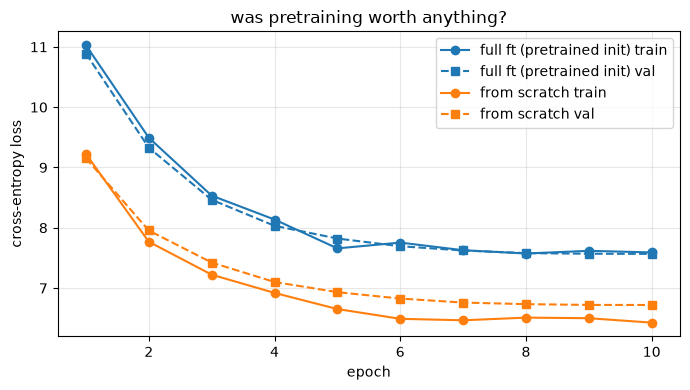

### from scratch (no pretraining)
  -- exact match, training examples --
   who_said=7.1% | reverse=0.0% | overall=2.0%
  -- exact match, held-out examples --
   XX  who_said: 'DUKE VINCENTIO'                       want 'QUEEN MARGARET'
   XX   reverse: 'gnit'                                 want 'nierehw'
   XX   reverse: 'gnit'                                 want 'sedivorp'
   XX   reverse: 'gnit'                                 want 'deyd'
   who_said=15.1% | reverse=0.0% | overall=5.3%
  gap: -3.3%
  -- continue (generative) --
   answer loss 5.011 | prompt-conditioned 65.0%   (50% = ignoring the prompt)
   ask  'continue:  here you sty me\nIn this hard rock, whiles'
   got  ",\nAnd I am, and I'll the king,"
   true " you do keep from me\nThe rest o' the island"
   ask  'go on:  for the mischance of\nthe hour, if it so'
   got  ",\nAnd I have the king,\nAnd I'll"
   true ' hap. Cheerly, good hearts! Out\n'
   ask  'what comes next: , bountiful Fortune,\nNow my dear lady, hath'
   

In [26]:
# TODO: the optional task
# ── Was pretraining worth anything? Same model, same schedule, random initialisation ──

# "On the instruction data alone": no replay. The full fine-tune's loader mixes in ~2,500
# pretraining windows per epoch (~1 pretraining epoch over 10 fine-tuning epochs), which would
# hand the scratch model part of the pretraining for free. Set True for the second arm
# described below (same data as full ft, so the ONLY difference is the initialisation).
SCRATCH_WITH_REPLAY = False

# Same architecture and vocabulary as the fine-tuned model (incl. the 4 template tokens)
scratch_config = copy.deepcopy(base_model.config)
assert scratch_config.vocab_size == len(tokenizer)
torch.manual_seed(1337)
scratch_model = TinyGPT(scratch_config).to(device)
describe(scratch_model, "from scratch")

scratch_train_loader = (
    sft_train_loader if SCRATCH_WITH_REPLAY else
    DataLoader(sft_train, batch_size=config.batch_size, shuffle=True, drop_last=True,
               num_workers=NUM_WORKERS))

# Same schedule as Task II: optimizer groups, lr, epochs, warmup + cosine, GPT-1 loss.
# The cosine is defined against this loader's own length, so it also ends at zero.
scratch_steps = FT_EPOCHS * len(scratch_train_loader)
opt = AdamW(param_groups(scratch_model), lr=FT_LR)
scratch_trainer = Trainer(
    model=scratch_model,
    train_data_loader=scratch_train_loader,
    test_data_loader=sft_val_loader,           # same validation set as every other run
    loss_fn=SFTWithAuxLM(lam=AUX_LM_LAMBDA),
    gradient_accumulation_steps=1,
    optimizer=opt,
    scheduler=cosine_with_warmup(opt, scratch_steps),
    device=device,
    save_dir="./checkpoints/tp2_scratch" + ("_replay" if SCRATCH_WITH_REPLAY else ""),
    save_every_n=500,
)
history_scratch = run_training(scratch_trainer, epochs=FT_EPOCHS)

# Validation curves are directly comparable (same instructions-only val set, same loss).
# Train curves are not if the loaders differ: replay batches are easier/harder than SFT ones.
plot_losses({"full ft (pretrained init)": history_full, "from scratch": history_scratch},
            title="was pretraining worth anything?")

acc_scratch_train, acc_scratch = evaluate_both(scratch_model, "from scratch (no pretraining)")

# One table: instruction metrics + the pretraining objective itself (Task IV).
rows = []
for name, m, hist, acc in (("full ft (pretrained)", full_ft_model, history_full, acc_full),
                           ("from scratch", scratch_model, history_scratch, acc_scratch)):
    q = continuation_quality(m, val_examples)
    rows.append((name, hist["val"][-1], acc["who_said"], acc["reverse"],
                 q["loss"], q["conditioned"], shakespeare_loss(m)))

print(f"\n{'':22s} {'SFT val':>8s} {'who_said':>9s} {'reverse':>8s} "
      f"{'cont loss':>10s} {'cond.':>6s} {'Shakesp.':>9s}")
for name, v, ws, rv, cl, cond, sh in rows:
    print(f"{name:22s} {v:8.3f} {ws:9.1%} {rv:8.1%} {cl:10.3f} {cond:6.1%} {sh:9.3f}")
print("(who_said / reverse: held-out exact match | cont loss / cond.: `continue` answer loss and"
      " prompt-conditioned share, 50% = chance | Shakesp.: Task IV loss on the pretraining val set)")

## Commentary on the optional taks
The result is mixed. On the losses, the model trained from scratch did better: SFT val loss 6.720 against 7.567, and continue answer loss 5.011 against 5.419. On the instruction metrics, the pretrained model is ahead or equal. who_said 20.8% against 15.1% and conditioning 65.8% against 65.0%. Those gaps are small for the sample sizes. On who_said the difference is 11 against 8 correct answers out of 53, and conditioning is measured on 120 examples, so I read them as a tie. The only clear advantage of pretraining is on the pretraining objective itself, 5.318 against 5.554 on the Shakespeare loss. Even so, the scratch model reached almost the base model’s 5.514 without any pretraining. So pretraining bought very little here, and the reason is scale. Pretraining used 30,645 tokens, while the instruction data is mined from the full corpus, about ten times more Shakespeare, so whatever the pretrained model knew, the fine-tuning data teaches it again and more. The pretrained model’s worse loss points to optimisation rather than knowledge. Its weights are fitted to 90k characters, and a learning rate of 3e-4 may not be enough to move them, while the random model has nothing to undo. There are two confounds. The scratch model trained without replay (SCRATCH_WITH_REPLAY = False), so all of its gradient went to the instructions. And each arm is a single run. To separate knowledge from optimisation, I would first run the arm with SCRATCH_WITH_REPLAY = True, so the initialisation is the only difference. Then I would fine-tune from a “shuffled” pretrained model: permute the entries of each pretrained matrix, which keeps the scale and statistics of each layer but destroys what it learned. If the shuffled model behaves like the pretrained one, the effect is optimisation, If it behaves like the scratch model, it is knowledge. A second check is to repeat this with more pretraining (0, 30k and 300k tokens). If the gain grows with the amount of pretraining text, it is knowledge.

# Task V — talk to it

Everything above is measurement. This is the whole inference path: apply the template,
sample a reply, stop at `<|end|>`.

You already wrote most of it. TP-1 Task I gave you `generateV2`, with temperature, top-k,
top-p and the KV-cache. Port it into `chat()` — three things are missing:

| gap | what to add | why it matters |
|---|---|---|
| no stop condition | break when the sampled token is `END_ID` | TP-1 always ran to `max_new_tokens`; a chat model decides when it is done |
| returns prompt + completion | return the reply only | a reply is the answer, not an echo of the question |
| no logit suppression | set the `<\|user\|>`, `<\|assistant\|>`, `<\|pad\|>` logits to `-inf` | otherwise it samples chat scaffolding into the middle of a reply |

Two notes. TP-1 typed the tokenizer argument as `CharTokenizer`, but the HuggingFace one
duck-types on `.encode`/`.decode`, so it drops in unchanged. And **sample, do not decode
greedily** — greedy is right for scoring because it is deterministic, but it loops badly
on a model this small (`and the people, and the people`).

In [27]:
# TODO: Task V
from transformers import GenerationConfig
from transformers.generation.logits_process import (
    LogitsProcessorList,
    TemperatureLogitsWarper,
    TopPLogitsWarper,
)

# Template tokens that must never appear inside a reply. END is not here: it is how a reply ends.
SUPPRESS_IDS = [tokenizer.convert_tokens_to_ids(t) for t in (USER, ASSISTANT, PAD)]


@torch.no_grad()
def chat(model, message: str, temperature: float = 0.8, top_p: float = 0.9,
         max_new_tokens: int = 24, seed: Optional[int] = None) -> str:
    """
    One turn: wrap `message` in the chat template, sample a reply, stop at <|end|>.

    Start from your TP-1 `generateV2` -- the sampling is already there. The three gaps
    are listed above.
    """
    model.eval()
    device = next(model.parameters()).device
    block_size = model.config.block_size

    # --- unchanged from generateV2: HF validation + the warper stack ---------------------
    # Always sampling: greedy is right for scoring, but loops on a model this small.
    gen_config = GenerationConfig(
        do_sample=True,
        max_new_tokens=max_new_tokens,
        temperature=temperature if temperature is not None else 1.0,
        top_p=top_p if top_p is not None else 1.0,  # HF sentinel for "no truncation"
    )
    gen_config.validate()

    warpers = LogitsProcessorList()
    if gen_config.temperature != 1.0:
        warpers.append(TemperatureLogitsWarper(gen_config.temperature))
    if gen_config.top_p < 1.0:
        warpers.append(TopPLogitsWarper(gen_config.top_p))

    # `seed` makes one reply reproducible, without touching the global RNG
    gen = torch.Generator(device=device)
    if seed is not None:
        gen.manual_seed(seed)

    # --- new: the chat template, exactly as in fine-tuning: "<|user|>{message}<|assistant|>"
    prompt, _ = format_example(("chat", message, ""))
    idx = torch.tensor(tokenizer.encode(prompt), dtype=torch.long, device=device)[None, :]
    reply: List[int] = []
    kv_cache = None

    for _ in range(gen_config.max_new_tokens):
        # --- unchanged from generateV2: cropped context first, then the KV-cache --------
        if kv_cache is None:
            idx_cond = idx[:, -block_size:]
        else:
            idx_cond = idx[:, -1:]

        logits, kv_cache = model(idx_cond, kv_cache=kv_cache, use_cache=True)
        kv_cache = trim_kv_cache(kv_cache, block_size - 1)

        step_logits = logits[:, -1, :].float().clone()

        # Gap 3 -- logit suppression, BEFORE the warpers: a -inf logit can never be kept
        # by top-p nor sampled, so no chat scaffolding lands inside a reply.
        step_logits[:, SUPPRESS_IDS] = float("-inf")

        step_logits = warpers(idx, step_logits)
        probs = F.softmax(step_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1, generator=gen)

        # Gap 1 -- stop condition: the model decides when the reply is over.
        if int(next_token) == END_ID:
            break
        reply.append(int(next_token))
        idx = torch.cat((idx, next_token), dim=1)

    # Gap 2 -- the reply only: no prompt, no <|end|>.
    return tokenizer.decode(reply)



for msg in ("continue: To be, or not to be,",
            "finish this: First Citizen:\nBefore we proceed",
            "who said: Now is the winter of our discontent",
            "reverse: sword"):
    print(f"> {msg}")
    print(f"  {chat(full_ft_model, msg, seed=0)!r}\n")


> continue: To be, or not to be,
  '.\n\nFirst Citizen:\nWhat.\n\nJUL, let,\nWith'

> finish this: First Citizen:
Before we proceed
  'ou'

> who said: Now is the winter of our discontent
  'QUEEN ELIZABETH'

> reverse: sword
  'yl sunsyl'



# Task VI — what does it attend to?

Task II showed that the model routes on the instruction: the same input under `continue`
and under `reverse` produces different answers. This asks *how*.

At the `<|assistant|>` position — the moment before it commits to a first answer token —
which tokens does attention actually weight? The task marker (`continue`, `who_said`), or
the content that follows it?

You visualised attention in TP-1 Task IV. `tinygpt.visualize_attention` still works, with
one catch: it calls `tokenizer.itos[i]`, which a HuggingFace tokenizer does not have. Fix
that line, or print the weights as a table.

`model(idx, return_weights=True)` returns `(logits, weights)`, where each layer's entry is
shaped `(n_head, B, T, T_k)`. Average over heads and take the last query row.

Report what the answer position looks at for one example of each task, and connect it to
the accuracy you measured in Task II.

In [28]:
# TODO: Task VI
@torch.no_grad()
def attention_at_answer(model, message: str, layer: int = -1, top: int = 6) -> None:
    """
    Print the tokens the <|assistant|> position attends to most, for one prompt.

    Hint: mean over heads of weights[layer][:, 0, -1, :].
    """
    model.eval()
    device = next(model.parameters()).device

    # The exact prompt chat() feeds the model: "<|user|>{message}<|assistant|>".
    # Its last position is <|assistant|> -- the moment before the first answer token.
    prompt, _ = format_example(("chat", message, ""))
    ids = tokenizer.encode(prompt)[-model.config.block_size:]
    idx = torch.tensor(ids, dtype=torch.long, device=device)[None, :]

    _, weights = model(idx, return_weights=True)          # per layer: (n_head, B, T, T_k)
    attn = weights[layer][:, 0, -1, :].float().mean(dim=0).cpu()   # (T_k,) sums to 1

    # HF tokenizers have no .itos: decode each id on its own to label it
    labels = [tokenizer.decode([i]).replace("\n", "\\n") for i in ids]

    # Split the prompt into template / task marker / content, to answer "marker or content?"
    task = message.split(":", 1)[0] + ":"                 # e.g. "continue:" or "who said:"
    n_marker = len(tokenizer.encode(f"{USER}{task}")) - 1 # marker tokens after <|user|>
    special = {tokenizer.convert_tokens_to_ids(t) for t in (USER, ASSISTANT)}
    kind = []
    for pos, i in enumerate(ids):
        if i in special:
            kind.append("template")
        elif ids[0] == tokenizer.convert_tokens_to_ids(USER) and 1 <= pos <= n_marker:
            kind.append("marker")
        else:
            kind.append("content")

    n_layers = len(weights)
    print(f"> {message!r}   (layer {layer % n_layers + 1}/{n_layers}, mean over heads)")
    # Uniform attention would give each group its share of tokens: the baseline to beat.
    print(f"   {'':<9} {'attention':>9} {'uniform':>8}")
    for name in ("marker", "content", "template"):
        mass = sum(float(a) for a, k in zip(attn, kind) if k == name)
        print(f"   {name:<9} {mass:9.1%} {kind.count(name) / len(kind):8.1%}")
    print(f"   top {top} tokens:")
    for pos in attn.argsort(descending=True)[:top].tolist():
        bar = "█" * int(round(40 * float(attn[pos])))
        print(f"     pos {pos:2d}  {labels[pos]!r:<16} {kind[pos]:<8} {float(attn[pos]):5.3f} {bar}")
    print()


for m in ("continue: To be, or not to be,", "who said: Now is the winter",
          "reverse: sword"):
    attention_at_answer(full_ft_model, m)


> 'continue: To be, or not to be,'   (layer 2/2, mean over heads)
             attention  uniform
   marker        15.6%    16.7%
   content       51.4%    66.7%
   template      33.0%    16.7%
   top 6 tokens:
     pos 11  '<|assistant|>'  template 0.325 █████████████
     pos  9  ' be'            content  0.097 ████
     pos  1  'continue'       marker   0.094 ████
     pos 10  ','              content  0.092 ████
     pos  6  ' or'            content  0.074 ███
     pos  5  ','              content  0.069 ███

> 'who said: Now is the winter'   (layer 2/2, mean over heads)
             attention  uniform
   marker        25.8%    33.3%
   content       26.8%    44.4%
   template      47.4%    22.2%
   top 6 tokens:
     pos  8  '<|assistant|>'  template 0.433 █████████████████
     pos  6  ' the'           content  0.111 ████
     pos  3  ':'              marker   0.107 ████
     pos  1  'who'            marker   0.093 ████
     pos  7  ' winter'        content  0.065 ███
     pos  2

## Answer position
At the <|assistant|> position in layer 2, averaging over heads, most of the attention goes to that same token, 33% for continue, 46% for who said and 48% for reverse. The task word gets less than a uniform share in all three cases (17.2% against 16.7% for continue, 26.4% against 33.3% for who said, 25.1% against 40.0% for reverse). So in the last layer the model is not reading the instruction directly. The task is probably already encoded in the <|assistant|> vector by layer 1, which this measurement does not show. What changes between tasks is how much the content gets, and it follows the Task II accuracy. In continue the content takes 49%, mostly the last tokens (' be', ','), which are what the next token depends on, and this is the task that works. In who said it takes 23%, mostly function words like ' the', matching the low 15%. In reverse the word itself gets 12.4%, below the uniform share, and the task scores 0%.

# Is the model still healthy?

Accuracy is not the only thing worth measuring. A model that scores 0% but emits
well-formed, terminating replies is still a working generator; one that emits `!` for ever
is not, whatever its loss says.

Two properties: replies **stop on their own** at `<|end|>`, and the model is **still a
language model** — pretraining loss near the base model's.

In [29]:
@torch.no_grad()
def generation_health(model, name: str, n: int = 60) -> None:
    """Does it terminate, and is it still a language model? Not accuracy."""
    lengths = [len(tokenizer.encode(generate_until(model, format_example(ex)[0])))
               for ex in val_examples[:n]]
    stopped = sum(1 for L in lengths if L < 24)      # 24 is generate_until's cap
    print(f"{name:>9} | {100 * stopped / n:>9.1f}% | {sum(lengths) / n:>9.1f} | "
          f"{shakespeare_loss(model):>10.3f}")


print(f"{'model':>9} | {'terminates':>10} | {'mean len':>9} | {'lm loss':>10}")
print("-" * 48)
for nm, m in (("base", base_model), ("full ft", full_ft_model), ("lora", lora_model)):
    generation_health(m, nm)

ex = next(e for e in val_examples if e[0] == "continue")
print(f"\nsample response to {format_example(ex)[0]!r}:")
print(f"  {generate_until(full_ft_model, format_example(ex)[0], max_new_tokens=20)!r}")
print("\nHealthy = terminates on its own AND keeps lm loss near the base model's.")

    model | terminates |  mean len |    lm loss
------------------------------------------------
     base |       0.0% |      24.0 |      5.514
  full ft |     100.0% |       4.6 |      5.318
     lora |     100.0% |       5.9 |      5.174

sample response to '<|user|>continue:  here you sty me\nIn this hard rock, whiles<|assistant|>':
  '\nAnd the the a,\nAnd the the'

Healthy = terminates on its own AND keeps lm loss near the base model's.


# ⚠️ Keep your checkpoints

`Trainer` writes `checkpoint_final.pt` at the end of every epoch, so a completed run has
already left these on your machine:

```
./checkpoints/tp2_full_ft/checkpoint_final.pt
./checkpoints/tp2_lora/checkpoint_final.pt
```

**You do not hand these in — just do not delete them.** TP-3 continues from the model you
fine-tuned here rather than training a new one. If you clear `./checkpoints/` you will have
to run Task II and Task III again, which is most of the runtime of this notebook.

Run the cell below before you finish, and make sure both lines say `ok`.

In [30]:
import os

print("files TP-3 will continue from -- keep these locally:\n")
missing = 0
for p in ("./checkpoints/tp2_full_ft/checkpoint_final.pt",
          "./checkpoints/tp2_lora/checkpoint_final.pt"):
    exists = os.path.exists(p)
    missing += not exists
    size = f"{os.path.getsize(p) / 1e6:>6.0f} MB" if exists else "   MISSING"
    print(f"  [{'ok' if exists else '!!'}] {p:<46} {size}")

print("\nkeep this directory -- TP-3 continues from it rather than retraining."
      if not missing else
      "\nrun Task II and Task III to completion before moving on to TP-3.")


files TP-3 will continue from -- keep these locally:

  [ok] ./checkpoints/tp2_full_ft/checkpoint_final.pt      78 MB
  [ok] ./checkpoints/tp2_lora/checkpoint_final.pt         78 MB

keep this directory -- TP-3 continues from it rather than retraining.


# Conclusions

- Prompt masking and the template were enough to turn a language model into one that follows a format. Both fine-tuned models stop on their own in 100% of cases, while the base model never did. What each task achieved depended on how close it was to the pretraining objective. continue worked (63% conditioning), who_said was weak but above chance (15.1% against 3.5%), and reverse stayed at 0% because the tokenizer hides the characters it needs.

- LoRA reached close to full fine-tuning on continue and kept a slightly lower Shakespeare loss. To work at all, though, it needed 13,606 vocabulary rows unfrozen, so 26.72% of the model moves, not the 0.09% of the adapters. With 98.4% of the parameters in the embedding and the head, a model this size has little room to be parameter-efficient.

- The Shakespeare loss did not show forgetting, because the fine-tuning data is more Shakespeare and includes the validation text. Generation did show it. Without a template, both models insert chat tokens into plain text. Dropping L1 (λ = 0) made the forgetting appear in the loss too (5.845, above the base model’s 5.514). The model trained from scratch roughly tied with the pretrained one, so at this scale the 30k tokens of pretraining were worth less than the fine-tuning data itself. Several of the instruction metrics rest on small samples (53 who_said examples, 120 for conditioning), so only gaps of several points mean much.

# Congratulations! 🎉

Across two notebooks you pretrained a GPT, implemented the decoding strategies that
turn it into a text generator, made it sparse with a Mixture of Experts, and aligned it
to a task with both full fine-tuning and LoRA.

That is the whole modern LLM pipeline, at a scale you can read end to end.